<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Simulacion-I/blob/main/Problema_rata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problema de la rata

Una rata en un laberinto se mueve aleatoriamente. Si hay $k$ formas de abandonar un laberinto, elije una salida con probabilidad $\frac{1}{k}$. ¿Cuál es la probabilidad de que la ratas encuentre primero la comida antes que el electroshock en el siguiente laberinto?

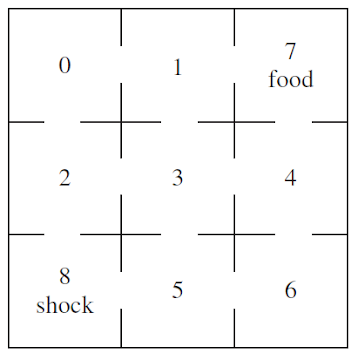

Importamos las librerías

In [4]:
import random as r
import collections
import numpy as np

In [52]:
def CM(alpha, P, max_pasos, estados_a):
    esta = np.arange(len(alpha))

    X_0 = np.random.choice(esta, p=alpha)

    secu = [X_0]

    for i in range(1, max_pasos + 1):
        pro_es = secu[-1]
        if pro_es in estados_a:
            return pro_es

        pro_tran = P[pro_es]

        if np.sum(pro_tran) == 0:
            return pro_es

        si_esta = np.random.choice(esta, p=pro_tran)
        secu.append(si_esta)

        if si_esta in estados_a:
            return si_esta

    return -1

In [64]:
alpha = np.array([1/7, 1/7, 1/7, 1/7, 1/7, 1/7, 1/7, 0, 0])
P = np.array([
    [0, 1/2, 1/2, 0, 0, 0, 0, 0, 0],
    [1/3, 0, 0, 1/3, 0, 0, 0, 1/3, 0],
    [1/3, 0, 0, 1/3, 0, 0, 0, 0, 1/3],
    [0, 1/4, 1/4, 0, 1/4, 1/4, 0, 0, 0],
    [0, 0, 0, 1/3, 0, 0, 1/3, 1/3, 0],
    [0, 0, 0, 1/3, 0, 0, 1/3, 0, 1/3],
    [0, 0, 0, 0, 1/2, 1/2, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1]
])
n = 1000

In [66]:
estados_a = [7, 8]
resultados = []
max_simu = 1000

for _ in range(n):
    estado_f = CM(alpha, P, max_simu, estados_a)
    if estado_f != -1:
        resultados.append(estado_f)

comida = resultados.count(7)
electroshock = resultados.count(8)

total_ce = len(resultados)

if total_ce > 0:
    prob_food = comida / total_ce
    prob_electroshock = electroshock / total_ce
else:
    prob_food = 0
    prob_electroshock = 0

print(f"Después de {n} simulaciones:")
print(f"Probabilidad de alcanzar la comida (estado 7): {prob_food:.4f}")
print(f"Probabilidad de alcanzar el electroshock (estado 8): {prob_electroshock:.4f}")

Después de 1000 simulaciones:
Probabilidad de alcanzar la comida (estado 7): 0.5130
Probabilidad de alcanzar el electroshock (estado 8): 0.4870
